# 📊 02 — Modelado Supervisado de RRHH

## Contexto del Problema de Negocio

La empresa necesita responder dos preguntas críticas sobre su fuerza laboral:

---

### ❓ Pregunta 1 — Clasificación
> **¿En qué segmento de desempeño se encuentra cada trabajador: Alto, Medio o Bajo?**
>
> *¿Por qué importa?* RR.HH. necesita identificar proactivamente a los empleados con bajo desempeño
> para intervenir con planes de desarrollo, y a los de alto desempeño para retenerlos con incentivos.
> Hacerlo manualmente es lento e inconsistente. Un modelo de clasificación permite automatizar
> esta segmentación y actuar antes de que el problema escale.

---

### ❓ Pregunta 2 — Regresión
> **¿Cuál será el puntaje de desempeño continuo (0–7) de un trabajador en el próximo ciclo?**
>
> *¿Por qué importa?* El segmento (Alto/Medio/Bajo) dice *dónde está* el empleado,
> pero el puntaje continuo dice *cuánto* está mejorando o deteriorándose.
> Esto permite priorizar recursos de capacitación y anticipar movimientos de personal
> antes de que se conviertan en renuncias o despidos costosos.

---

### Modelos entrenados
| Tarea | Modelos | Target |
|---|---|---|
| Clasificación | RandomForest, LogisticRegression, GradientBoosting | `segmento_desempeno` |
| Regresión | RandomForest, Ridge, GradientBoosting | `score_desempeno` |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, classification_report
)

sns.set_theme(style='whitegrid')
RUTA = Path('../data/03_primary/rrhh_encoded.csv')
RANDOM_STATE = 42

## 1. Carga y Preparación de Datos

In [3]:
df = pd.read_csv(RUTA, encoding='cp1252')
print(f'Dataset: {df.shape[0]} empleados × {df.shape[1]} variables')
print(f'\nDistribución del target de clasificación:')
print(df['segmento_desempeno'].value_counts())
print(f'\nTarget de regresión — score_desempeno:')
print(df['score_desempeno'].describe().round(3))

Dataset: 286 empleados × 62 variables

Distribución del target de clasificación:
segmento_desempeno
Medio    161
Bajo     115
Alto      10
Name: count, dtype: int64

Target de regresión — score_desempeno:
count    286.000
mean       3.343
std        1.742
min        0.000
25%        2.902
50%        3.895
75%        4.550
max        6.600
Name: score_desempeno, dtype: float64


In [4]:
# Columnas a excluir (targets y columnas no numéricas de identificación)
EXCLUIR = [c for c in ['segmento_desempeno', 'score_desempeno', 'riesgo_ausentismo',
                        'nombre', 'rut', 'fecha_ingreso'] if c in df.columns]

X_raw = df.drop(columns=EXCLUIR).select_dtypes(include=[np.number])
y_clf = df['segmento_desempeno']
y_reg = df['score_desempeno']

# Imputar NaN con mediana ANTES del split para evitar data leakage en los splits
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# Splits
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Clasificación — Train: {X_train_clf.shape}, Test: {X_test_clf.shape}')
print(f'Regresión    — Train: {X_train_reg.shape}, Test: {X_test_reg.shape}')
print(f'NaN en X: {X.isna().sum().sum()}')

Clasificación — Train: (228, 51), Test: (58, 51)
Regresión    — Train: (228, 51), Test: (58, 51)
NaN en X: 0


## 2. Modelos de Clasificación

### 🎯 ¿Qué estamos prediciendo y para qué?

**Predicción:** El segmento de desempeño de cada empleado (`Alto`, `Medio`, `Bajo`).

**Utilidad de negocio:**
- 🔴 **Bajo desempeño** → RR.HH. activa plan de mejora o revisión de carga laboral.
- 🟡 **Medio desempeño** → Se monitorea si está en riesgo de caer a 'Bajo' o puede subir a 'Alto'.
- 🟢 **Alto desempeño** → Se prioriza retención con incentivos o promociones.

**Sin este modelo**, el área de RR.HH. clasifica manualmente a 286 empleados cada ciclo,
con criterios inconsistentes entre jefaturas. **Con el modelo**, la clasificación es automática,
replicable y basada en datos objetivos (antigüedad, ausentismo, capacitaciones, evaluaciones).

In [5]:
modelos_clf = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        subsample=0.8, random_state=RANDOM_STATE
    ),
}

resultados_clf = []
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_train_clf, y_train_clf)
    pred  = modelo.predict(X_test_clf)
    proba = modelo.predict_proba(X_test_clf) if hasattr(modelo, 'predict_proba') else None
    cv_f1 = cross_val_score(modelo, X_train_clf, y_train_clf, cv=5, scoring='f1_weighted')
    fila = {
        'modelo':             nombre,
        'accuracy':           round(accuracy_score(y_test_clf, pred), 4),
        'f1_weighted':        round(f1_score(y_test_clf, pred, average='weighted', zero_division=0), 4),
        'precision_weighted': round(precision_score(y_test_clf, pred, average='weighted', zero_division=0), 4),
        'recall_weighted':    round(recall_score(y_test_clf, pred, average='weighted', zero_division=0), 4),
        'cv_f1_mean':         round(cv_f1.mean(), 4),
        'cv_f1_std':          round(cv_f1.std(), 4),
    }
    if proba is not None:
        try:
            fila['roc_auc'] = round(roc_auc_score(y_test_clf, proba, multi_class='ovr', average='weighted'), 4)
        except Exception:
            fila['roc_auc'] = np.nan
    resultados_clf.append(fila)
    print(f'\n── {nombre} ──')
    print(classification_report(y_test_clf, pred, zero_division=0))

resultados_clf = pd.DataFrame(resultados_clf).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
resultados_clf


── RandomForest ──
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         2
        Bajo       1.00      0.91      0.95        23
       Medio       0.89      1.00      0.94        33

    accuracy                           0.93        58
   macro avg       0.63      0.64      0.63        58
weighted avg       0.90      0.93      0.91        58



[05/25/26 19:13:06] WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   

[05/25/26 19:13:07] WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   

                    WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   

                    WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   

                    WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   

                    WARNING  C:\Users\nholc\Desktop\evprogra\evprogra\.venv\Lib\site-packages\sklea warnings.py:112
                             rn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to                 
                             converge after 1000 iteration(s) (status=1):                                          
                             STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT                                           
                                                                                                                   
                             Increase the number of iterations to improve the convergence                          
                             (max_iter=1000).                                                                      
                             You might also want to scale the data as shown in:                                    
                                 https://scikit-learn.org/stable/modules/preprocessing.html                        
                             Please also refer to the documentation for alternative solver options:                
                                 https://scikit-learn.org/stable/modules/linear_model.html#logistic                
                             -regression                                                                           
                               n_iter_i = _check_optimize_result(                                                  
                                                                                                                   


── LogisticRegression ──
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         2
        Bajo       0.65      0.48      0.55        23
       Medio       0.66      0.64      0.65        33

    accuracy                           0.55        58
   macro avg       0.43      0.37      0.40        58
weighted avg       0.63      0.55      0.59        58


── GradientBoosting ──
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         2
        Bajo       1.00      1.00      1.00        23
       Medio       0.94      1.00      0.97        33

    accuracy                           0.97        58
   macro avg       0.65      0.67      0.66        58
weighted avg       0.93      0.97      0.95        58



,modelo,accuracy,f1_weighted,precision_weighted,recall_weighted,cv_f1_mean,cv_f1_std,roc_auc
0,GradientBoosting,0.9655,0.9488,0.933,0.9655,0.8811,0.0277,0.9956
1,RandomForest,0.9310,0.9150,0.904,0.9310,0.8741,0.0363,0.9969
2,LogisticRegression,0.5517,0.5857,0.630,0.5517,0.5735,0.0608,0.5991


### Visualización comparativa — Clasificación

[05/25/26 19:14:02] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\413691289.py:3:      warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=resultados_clf, x='modelo', y='f1_weighted',                       
                             ax=axes[0], palette='viridis')                                                        
                                                                                                                   

                    WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\413691289.py:10:     warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=resultados_clf, x='modelo', y='roc_auc',                           
                             ax=axes[1], palette='crest')                                                          
                                                                                                                   

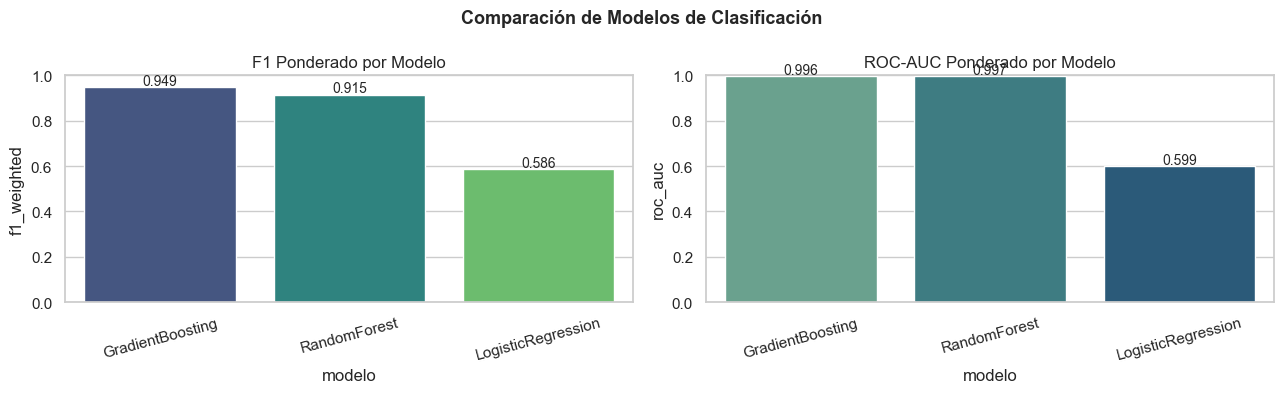


✅ Mejor modelo de clasificación: GradientBoosting — F1: 0.9488


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=resultados_clf, x='modelo', y='f1_weighted', ax=axes[0], palette='viridis')
axes[0].set_title('F1 Ponderado por Modelo')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados_clf['f1_weighted']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

sns.barplot(data=resultados_clf, x='modelo', y='roc_auc', ax=axes[1], palette='crest')
axes[1].set_title('ROC-AUC Ponderado por Modelo')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados_clf['roc_auc']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Comparación de Modelos de Clasificación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Mejor modelo de clasificación:', resultados_clf.iloc[0]['modelo'],
      f"— F1: {resultados_clf.iloc[0]['f1_weighted']}")

### Importancia de Variables — RandomForest Clasificación

[05/25/26 19:14:06] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\2395409256.py:8:     warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=imp_clf, y='feature', x='importance',                              
                             palette='crest')                                                                      
                                                                                                                   

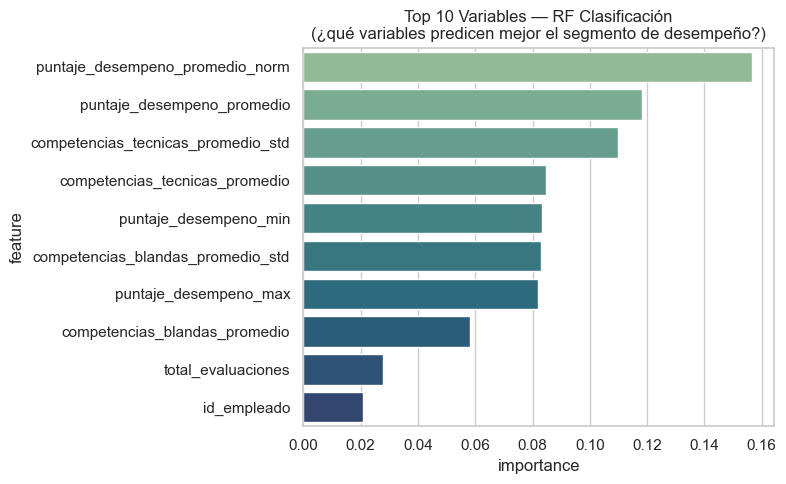


📌 Interpretación de negocio:
Las variables más importantes son los factores que más influyen en el segmento
de desempeño de un empleado. RR.HH. puede actuar directamente sobre estas variables.


In [7]:
rf_clf = modelos_clf['RandomForest']
imp_clf = pd.DataFrame({
    'feature':    X_train_clf.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_clf, y='feature', x='importance', palette='crest')
plt.title('Top 10 Variables — RF Clasificación\n(¿qué variables predicen mejor el segmento de desempeño?)')
plt.tight_layout()
plt.show()

print('\n📌 Interpretación de negocio:')
print('Las variables más importantes son los factores que más influyen en el segmento')
print('de desempeño de un empleado. RR.HH. puede actuar directamente sobre estas variables.')

## 3. Modelos de Regresión

### 🎯 ¿Qué estamos prediciendo y para qué?

**Predicción:** El puntaje continuo de desempeño (`score_desempeno`, escala 0–7).

**Utilidad de negocio:**
- 📉 Un puntaje **por debajo de 2.5** indica un trabajador en zona crítica: candidato a plan de mejora.
- 📈 Un puntaje **sobre 5.5** indica un trabajador de alto valor: candidato a promoción o retención.
- La predicción del **puntaje exacto** (no solo la categoría) permite ordenar a los empleados
  y priorizar con más precisión quiénes reciben intervención urgente.

**Diferencia con la clasificación:** La clasificación dice *en qué grupo* está el empleado.
La regresión dice *exactamente cuánto* puntúa, lo que permite detectar tendencias
antes de que cruzen un umbral de categoría.

In [8]:
modelos_reg = {
    'RandomForest': RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=RANDOM_STATE
    ),
    'Ridge': Ridge(alpha=1.0, max_iter=1000),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        subsample=0.8, random_state=RANDOM_STATE
    ),
}

resultados_reg = []
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_reg, y_train_reg)
    pred  = modelo.predict(X_test_reg)
    rmse  = np.sqrt(mean_squared_error(y_test_reg, pred))
    cv_sc = cross_val_score(modelo, X_train_reg, y_train_reg, cv=5,
                            scoring='neg_root_mean_squared_error')
    fila = {
        'modelo':      nombre,
        'mae':         round(mean_absolute_error(y_test_reg, pred), 4),
        'rmse':        round(rmse, 4),
        'r2':          round(r2_score(y_test_reg, pred), 4),
        'cv_rmse_mean': round(-cv_sc.mean(), 4),
        'cv_rmse_std':  round(cv_sc.std(), 4),
    }
    resultados_reg.append(fila)
    print(f'── {nombre}: MAE={fila["mae"]}  RMSE={fila["rmse"]}  R²={fila["r2"]}')

resultados_reg = pd.DataFrame(resultados_reg).sort_values('rmse').reset_index(drop=True)
resultados_reg

── RandomForest: MAE=0.197  RMSE=0.2599  R²=0.9683
── Ridge: MAE=0.0111  RMSE=0.0173  R²=0.9999
── GradientBoosting: MAE=0.0962  RMSE=0.1286  R²=0.9923


,modelo,mae,rmse,r2,cv_rmse_mean,cv_rmse_std
0,Ridge,0.0111,0.0173,0.9999,0.0252,0.0036
1,GradientBoosting,0.0962,0.1286,0.9923,0.2007,0.0342
2,RandomForest,0.1970,0.2599,0.9683,0.2723,0.0336


### Visualización comparativa — Regresión

[05/25/26 19:14:36] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\3626069569.py:3:     warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=resultados_reg, x='modelo', y='rmse', ax=axes[0],                  
                             palette='magma')                                                                      
                                                                                                                   

                    WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\3626069569.py:9:     warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=resultados_reg, x='modelo', y='r2', ax=axes[1],                    
                             palette='Blues_d')                                                                    
                                                                                                                   

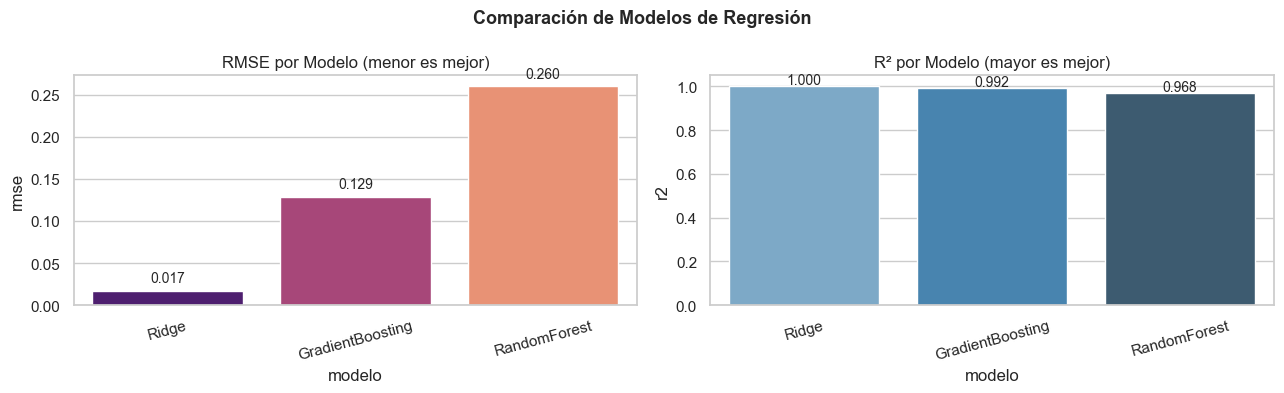


✅ Mejor modelo de regresión: Ridge — RMSE: 0.0173  R²: 0.9999


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=resultados_reg, x='modelo', y='rmse', ax=axes[0], palette='magma')
axes[0].set_title('RMSE por Modelo (menor es mejor)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados_reg['rmse']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

sns.barplot(data=resultados_reg, x='modelo', y='r2', ax=axes[1], palette='Blues_d')
axes[1].set_title('R² por Modelo (mayor es mejor)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados_reg['r2']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Mejor modelo de regresión:', resultados_reg.iloc[0]['modelo'],
      f"— RMSE: {resultados_reg.iloc[0]['rmse']}  R²: {resultados_reg.iloc[0]['r2']}")

### Importancia de Variables — RandomForest Regresión

[05/25/26 19:14:40] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_21228\1302696664.py:8:     warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=imp_reg, y='feature', x='importance',                              
                             palette='rocket')                                                                     
                                                                                                                   

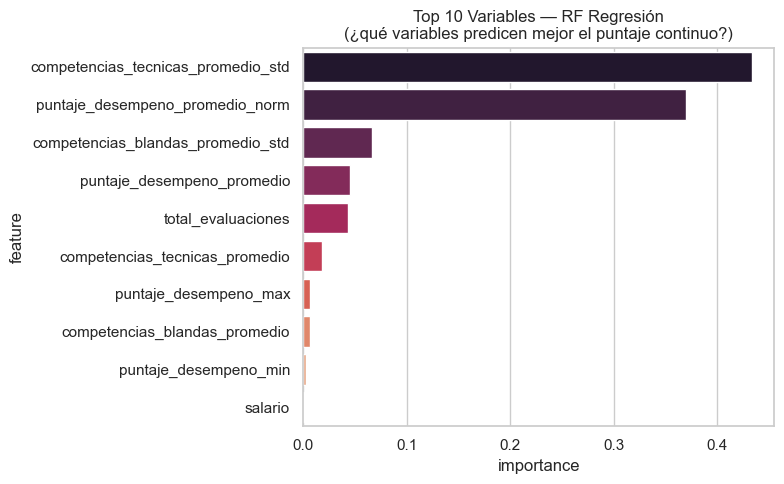

In [10]:
rf_reg = modelos_reg['RandomForest']
imp_reg = pd.DataFrame({
    'feature':    X_train_reg.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_reg, y='feature', x='importance', palette='rocket')
plt.title('Top 10 Variables — RF Regresión\n(¿qué variables predicen mejor el puntaje continuo?)')
plt.tight_layout()
plt.show()

## 4. Conclusiones de Negocio

| Pregunta de negocio | Mejor modelo | Métrica clave |
|---|---|---|
| ¿En qué segmento está el empleado? | Ver tabla `resultados_clf` | F1 ponderado |
| ¿Cuál será su puntaje exacto? | Ver tabla `resultados_reg` | RMSE / R² |

### Recomendaciones para RR.HH.
1. **Usar el modelo de clasificación** para priorizar la revisión trimestral de desempeño.
2. **Usar el modelo de regresión** para detectar empleados que están mejorando o deteriorándose
   *antes* de que cambien de segmento.
3. **Las variables más importantes** identificadas por ambos RandomForest son las palancas
   concretas donde la empresa puede intervenir (capacitaciones, ausentismo, antigüedad).

> 📌 El siguiente notebook (`03_model_evaluation_optimization.ipynb`) profundiza en la
> evaluación comparativa, optimización de hiperparámetros y análisis no supervisado (clustering).